# Pareto Frontier: KV Cache Compression Strategies
Generates a scatter plot of compression ratio vs perplexity delta for all benchmark strategies on Llama-3.2-1B-Instruct (WikiText-2).

**No GPU required** - uses existing benchmark results from Day 20.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# Results from Day 20 benchmark (Llama-3.2-1B-Instruct, WikiText-2, A100)
results = {
    'FullKV (baseline)': {'ppl': 11.15, 'compression': 1.0},
    'Stratigraphic':     {'ppl': 11.18, 'compression': 2.2},
    'INT8-all':          {'ppl': 11.15, 'compression': 1.9},
    'INT4-all':          {'ppl': 13.37, 'compression': 3.6},
    'SnapKV (50%)':      {'ppl': 17.94, 'compression': 2.0},
    'H2O (50%)':         {'ppl': 107.72, 'compression': 2.0},
}

baseline_ppl = results['FullKV (baseline)']['ppl']

Saved to /results/pareto_frontier.png


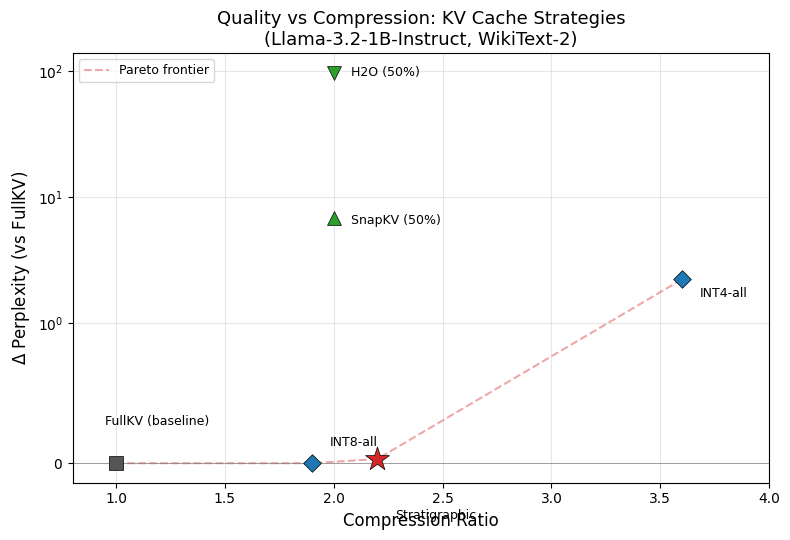

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))

# Colour and marker style per strategy category
style = {
    'FullKV (baseline)': {'c': '#555555', 'marker': 's', 'ms': 10},
    'Stratigraphic':     {'c': '#d62728', 'marker': '*', 'ms': 18},
    'INT8-all':          {'c': '#1f77b4', 'marker': 'D', 'ms': 9},
    'INT4-all':          {'c': '#1f77b4', 'marker': 'D', 'ms': 9},
    'SnapKV (50%)':      {'c': '#2ca02c', 'marker': '^', 'ms': 10},
    'H2O (50%)':         {'c': '#2ca02c', 'marker': 'v', 'ms': 10},
}

for name, r in results.items():
    delta = r['ppl'] - baseline_ppl
    s = style[name]
    ax.scatter(r['compression'], delta, c=s['c'], marker=s['marker'],
               s=s['ms']**2, zorder=5, edgecolors='black', linewidths=0.5)

# Annotate each point
offsets = {
    'FullKV (baseline)': (-0.05, 0.3),
    'Stratigraphic':     (0.08, -0.4),
    'INT8-all':          (0.08, 0.15),
    'INT4-all':          (0.08, -0.5),
    'SnapKV (50%)':      (0.08, -0.3),
    'H2O (50%)':         (0.08, 0.0),
}
for name, r in results.items():
    delta = r['ppl'] - baseline_ppl
    dx, dy = offsets[name]
    ax.annotate(name, (r['compression'], delta),
                xytext=(r['compression'] + dx, delta + dy),
                fontsize=9, ha='left', va='center')

# Pareto frontier line (connect non-dominated points)
# Non-dominated: FullKV(1.0, 0.0), INT8(1.9, 0.0), Stratigraphic(2.2, 0.03), INT4(3.6, 2.22)
pareto_x = [1.0, 1.9, 2.2, 3.6]
pareto_y = [0.0, 0.0, 0.03, 2.22]
ax.plot(pareto_x, pareto_y, '--', color='#d62728', alpha=0.4, linewidth=1.5, label='Pareto frontier')

ax.set_yscale('symlog', linthresh=1.0)
ax.set_xlabel('Compression Ratio', fontsize=12)
ax.set_ylabel(r'$\Delta$ Perplexity (vs FullKV)', fontsize=12)
ax.set_title('Quality vs Compression: KV Cache Strategies\n(Llama-3.2-1B-Instruct, WikiText-2)', fontsize=13)
ax.set_xlim(0.8, 4.0)
ax.axhline(y=0, color='grey', linewidth=0.5, linestyle='-')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = Path('../results/pareto_frontier.png')
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved to {save_path.resolve()}')
plt.show()